`<h2><center>Praktische Sterrenkunde</center></h2>
<h3><center>Observation Assignement 1: Messier 37</center></h3>
<center>Year 2024-2025<br></center>
<center><br>Dr. Ana Monreal Ibero<br><br></center>

## Introduction

In this practicum we will reduce the data obtained with the student telescope at the in the Old Observatory. For this we will use IPython and DS9.

Jupyter is an implementation of your well-known Python, where text and code can be placed in a single document. The code is simply Python (and more specifically written on the enhanced interactive shell IPython), but is divided into *cells*. Each cell can be seen as its own piece of code, which can be run separately. Cells can communicate with each other - this makes it easy to test code. So you can import images into one cell and edit them in the next - then you don't have to re-import every time to test your reduction.

To edit a cell, simply click on it. To run the code, press the play-button at the top of the window (triangle pointing to the right) or control+enter.

Plots and prints will appear below the relevant cell. For example, try to run the next cell (click on it and then press play or control+enter):

Here comes a plot!


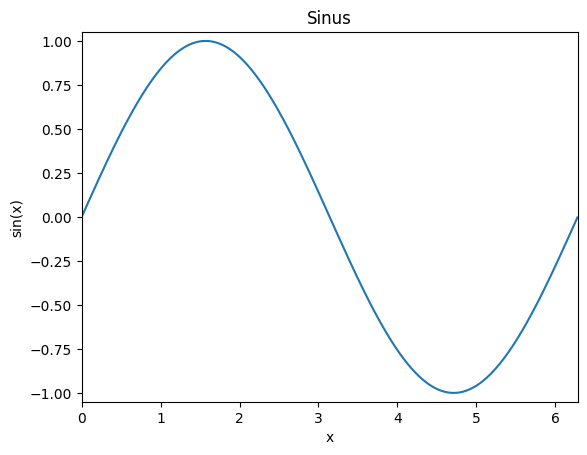

In [2]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

print("Here comes a plot!")

x = np.arange(0, 2*np.pi, 0.01) # x-coordinate
plt.plot(x, np.sin(x))          # plot x and the sine of x
plt.xlim(0, 2*np.pi)            # change x-range of the plot
plt.ylim(-1.05, 1.05)           # change y-range of the plot
plt.title("Sinus")              # give a title to the plot 
plt.xlabel("x")                 # attach a label to the x-axis
plt.ylabel("sin(x)")            # attach a label to the y-axis
plt.show()                      # show the plot

## Data

The images we have created are stored in *.fits* files. The *Flexible Image Transport System* (FITS) format is the worldwide standard in astronomy. These FITS files contain two parts: an image (the data) and a header (containing information such as who did the observation, when, etc.). They can be found on Brightspace within Content > Data > M37 Observations. You should download them to your laptop. 

Both image and header can be imported into Python with the astropy package. You can install it in your laptop following the instructions appearing here: https://www.astropy.org/ . If, for example, we want to import the dark-frame, we will run the next cell:

In [3]:
# Right now it does not work since it points to a non-exisiting place. You should replace this with your path
# For testing purposes I put an image of my own
from astropy.io import fits

path = rf"../raw_data/test_data/Dark_1.fits"
# @groepje
# Voor path om goed te werken moet je de locatie van het bestand goed hebben, 
# ik heb het zodat mijn code zit op .../Observing1/Code/TO3_DataRedu_M37.ipynb, en dat mijn data zit op .../Observing1/raw_data/test_data/Dark_1.fits 
# Of je zorgt dat je code zit met de zelfde structuur (dus hoofdmap/raw_data/test_data/Dark_1.fits) en dat je code zit in (hoofdmap/iets/code.ipynb)
# Of je past path aan terwijl je de code runt
dark = fits.open(path)[0] # note the [0] !



You will see that *dark* is a special object - an HDU (*Header Data Unit*). It contains both the data and the header with additional information. If we want to look at the header, we can print it out as follows:

In [4]:
#dark.header
dark.header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 4096 / length of data axis 1                          
NAXIS2  =                 4096 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
SBUUID  = '{5b8ca134-663b-4e29-9e1a-eea53336f83e}' / Photo UUID                 
EXPTIME =                   1. / SBIGFITSEXT Total exposure time in seconds     
SWCREATE= 'TheSkyX Version 1

This gives the complete header: all the information attached to the image in the .fits file. If you only want a single element of the header, you can call it up with the corresponding keyword. Thus the keyword for the filter is "FILTER":

In [5]:
# This does not work because my template image does not have the keyword FILTER.
# For testing purposes, I write another sentence below
# print("These image was taken with the following filter:", dark.header["FILTER"])
print("These are observations for target: ", dark.header["OBJECT"])

These are observations for target:  Mouse click position


We can access to the data in the same manner. They are simply storaged as a numerical array with the number of counts for each array element (pixel). This means that we can use all calculation methods from numpy without having to mess around with for-loops and the like.

In [6]:
dark.data

array([[2015, 1992, 1999, ..., 1991, 1999, 2005],
       [1999, 2002, 1998, ..., 1994, 2012, 1999],
       [2016, 1994, 2029, ..., 2012, 2003, 2006],
       ...,
       [1996, 2002, 2006, ..., 2016, 2001, 2003],
       [2013, 1990, 1998, ..., 2000, 1993, 2014],
       [1980, 1992, 2016, ..., 1980, 1988, 2009]], dtype=uint16)

***
### Exercise 1
Print the following data from the *dark* image:
* Exposure time in seconds
* Number of pixels in the image
* Universal Time at which the image was taken
* Local Sidereal Time at which the image was taken

In [7]:
print(f"Exposure time: {dark.header['EXPTIME']} seconds\n"
      f"Number of pixels: {dark.header['WID_VIS'] * dark.header['HT_VIS']}\n" 
      f"Universital time at observation: {dark.header['DATE-OBS']}\n"
      f"Local sidereal at observation: {dark.header['LST']}")

Exposure time: 1.0 seconds
Number of pixels: 16777216
Universital time at observation: 2019-02-25T17:32:42.070
Local sidereal at observation: +04 11 50.64


***
## Calibration

During the observatios, several types of calibration images are taken: dark, bias and flatfield. Each of these images is used to remove a different instrumental footprint from our data.

We want to combine our data with these calibrations, according to the following recipe:

$ flat_1 = (flat - bias) - (dark - bias) \times t_{flat} / t_{dark} $  
$ flat_2 = (flat_1\, / <flat_1> ) $  
$ light_1 = (light - bias) - (dark - bias) \times t_{light} / t_{dark} $  
$ science = light_1\, / flat_2 $

Here $t_i$ are the relevant exposure times, $<x>$ the average of $x$ and $science$ the final reduced image.

***
### Exercise 2

Apply the above recipe to the images you have downloaded.

The images are called Bias_x.fits, Dark_x.fits, Light_F_x.fits and Flat_F_x.fits (with F the relevant filter and x the file number). Combine multiple images to reduce noise (note exposure times!).

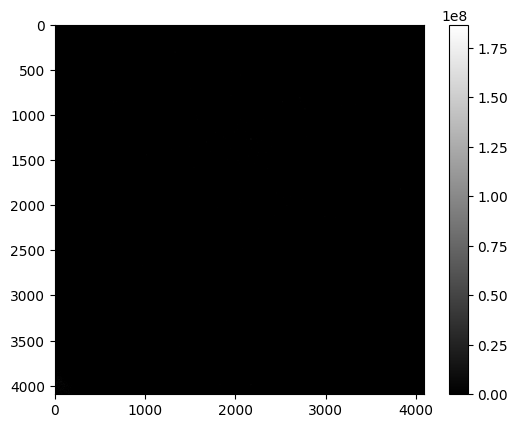

In [22]:
# Creating science imagine class
# we hebben meerdere foto's gemaakt op de avond zelf, daarom doe ik het met een object zodat we later betere code hebben
# TO-DO: goed de comment herschrijven voor de opdracht zelf ipv alleen voor ons
class science_image:
    def __init__(self, light, flat, dark, bias, t_flat, t_dark, t_light):
        # Only .data is relevant, other information is omitted
        light = light.data
        flat = flat.data
        dark = dark.data
        bias = bias.data

        # Calculating according to the formules given above, with added parentheses due to the assignment giving wrong information        
        self.flat_1 = ( (flat-bias) - (dark-bias) ) * (t_flat/t_dark) 
        self.flat_2 = self.flat_1 / np.mean(self.flat_1)
        self.light_1 = ( (light-bias) - (dark-bias) ) * (t_light/t_dark)
        self.science = self.light_1 / self.flat_2

# Loading data 
filter = "R" # PLACEHOLDER
base_path = r"../raw_data/test_data/" 
flat = fits.open(f"{base_path}Flat_{filter}.fits")[0]
dark = fits.open(f"{base_path}Dark_1.fits")[0] # ik snap nog niet of we nu dark_1 of dark_2 zouden moeten gebruiken
bias = fits.open(f"{base_path}Bias.fits")[0]
light = fits.open(f"{base_path}Light_{filter}.fits")[0]

def calibration(filter, base_path, dark_number):
    flat = fits.open(f"{base_path}Flat_{filter}.fits")[0]
    dark = fits.open(f"{base_path}Dark_{dark_number}.fits")[0]
    bias = fits.open(f"{base_path}Bias.fits")[0]

    return science_image(light, flat, dark, bias,
                        flat.header['EXPTIME'], dark.header['EXPTIME'], light.header['EXPTIME'])
image = calibration(filter, base_path, 1)

# Plotting result of the image reduction
plt.imshow(image.science, cmap="gray")
plt.colorbar()
plt.show() 
# deze plot geeft een beeld waar je eigenlijk niks op kan zien. geen flauw idee waarom
# ik heb een beetje gespeeld met welke filter en welke dark, maar zag weinig nuttigs.

# TO-DO: er staat "Combine multiple images to reduce noise (note exosure times!)" in de opdracht, ik snap nog niet precies hoe dit moet







Now save the science image you created above to a file. To do this you can use the function WT.saveFITS() from the module T03_ObsM37_tools.py. This module can be found on Brightspace under Contents > Tools > Tools for data reduction > Data reduction > Python module for night observations.

You pass your data array and the filename where you want to save the science image in that order to the function: WT.saveFITS(data, filename). The function will give an error if there is already a file with the name you passed to it. If you want to overwrite files, you can use this form: WT.saveFITS(data, filename, overwrite = True).

Also look at the help for the function by running help(WT.savefits).

Note that astropy must be installed to use the T03_ObsM37_tools file.

In [3]:
import T03_ObsM37_tools as WT
# Your code here!

***

## Counting photons

Now that we have the calibrated science image, we can start the photometric measurements. At the end of the day, we want to know the magnitudes in B, V and R of a number of stars in cluster M37. 

For a number of stars, we first want to select which pixels belong to the star (as the stars are spread over several pixels). For this we use the program *ds9*. If you do not have *ds9* installed, please visit https://sites.google.com/cfa.harvard.edu/saoimageds9 , go to download, and follow the instructions there. Depending on your operative system and the flavour of *ds9* that you download, you will have to open differently. If you work on a linux machine, you can open this by typing *ds9 &* in your console. With a Mac, you would have to type this or *open -a SAOImageDS9 &*, depending on what you downloaded.

Once you have opened ds9 you can open an image (via File, top left). Open your newly created science image. Now go to the tab *Scale* and select the options *log* and *zscale*. Now drag with the right mouse button to change the contrast, and zoom/shift the image until you have all the stars in the provided image clearly visible.

You can now draw *regions* around the stars. Click on a star and a green circle will appear. Click again to move it and make it larger/smaller. Make sure that each star has such a region, with all the light from the star falling within the circle and as little background as possible.

** It is important that you do this in the order shown in the image. **
***
### Exercise 3

Use the procedure above to select each of the 24 stars indicated. Finally, select a 25th region somewhere without stars, which we use this to measure the background.

Export your regions by going to the *Regions* tab, then clicking *Save regions* at the bottom, and then saving a .reg-file to the folder you're working in. Make sure you change *Coordinate System* from *wcs* to *physical*. (You can do this after pressing ok when saving).
***

This .reg-file contains the coordinates and radius for each region. These can be obtained in python using the *regextract* function from *WT*:

In [4]:
x, y, r = WT.regextract("ds9.reg") # replace ds9.reg with the name of your file. 
print("x-coordinates:")

print(x)

OSError: ds9.reg not found.

If you have any questions about a function in Python, first look at the documentation, using the command *help(function)*. You can often find examples and explanations in the documentation, and even the most common errors. You can put this command in a cell and run it to see the documentation.

We can now use the *aper* function from *WT* to measure how many photons have fallen within each of these regions.
For a particular region with coordinates *(x_i, y_i)* and radius *r_i*, you can measure the number of counts and the associated error. *aper* is a function that can do a lot for you and will also be used during the second year's practicum. However, in our case, we only want to measure the counts so most settings can be ignored. You use the function as follows:

In [5]:
x_i = 2000.
y_i = 2000.
r_i = 3. # examples

# science is your calibrated image - change it if you have called it otherwise
flux, eflux, sky, skyerr = WT.aper(science, xc=[x_i], yc=[y_i], apr=[r_i], phpadu=1., 
                        skyrad=[-1], flux=True, setskyval=0., silent=True) # Pay attention to the square brackets!


print(flux)
print(eflux)

NameError: name 'science' is not defined

*flux* and *eflux* now contain for this star the number of counts and the associated error. *sky* and *skyerr* are used to subtract the background, but as this is a densely populated area we will do this by hand. **You therefore do not need to save** *sky* **and** *skyerr* **.** 

***
### Exercise 4

Use *aper* to determine the number of counts and their error for each star and background region.

You want to pass each x, y and r separately to *aper*, so it is not possible to pass and array to this function. Thus, you could use, for example, a for-loop or list-comprehension. Furthermore, the x, y and r must always be given as a list, i.e. with square brackets around the individual number (i.e. '[x_B]'). For more information about lists and other data structures in python, see https://www.w3schools.com/python/python_lists.asp


In [6]:
flux = np.zeros(25)
eflux = np.zeros(25) # empty arrays to insert data

# Your code here!

***

We now have for each of our stars and a background field the number of counts and the associated error. Finally, we want to subtract the background from each of the stars so that we really only get the star flux. To do this, we use the following formula:

$ F_{star} = C_{star} - \frac{C_{background}}{A_{background}} \times A_{star} $

where $F_{star}$ is the final flux of a star, $C$ is the raw number of counts in a region, and $A$ is the area in pixels of a region.

(How do you calculate the area of a circle?)

***

### Exercise 5

Calculate the flux for each star according to the formula above. Also calculate the error on the stellar flux by calculating the error on the raw counts ($C$) and assuming a negligible error on the aperture areas ($A$).


In [7]:
# Your code here!

Save the calculated flux values and errors for each star in a .txt file. Print the values also in the format below:

Star 1: Flux +- Eflux  
Star 2: Flux +- Eflux  
etc. 

In [8]:
# Your code here!

***